\newpage

# <span style="color: #d9534f;"> Setup, Import, and Data Cleaning </span>

Data was imported using pandas 'read_excel'.

In [43]:
#| echo: false
#| output: false
# Import libraries.
import os

import pandas as pd

print(f"Pandas version: {pd.__version__}")

import numpy as np
print(f"Numpy version: {np.__version__}")

import openpyxl
print(f"Openpyxl version: {openpyxl.__version__}")

# When importing a sub-module so we don't do version checking on it directly.
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# For more plot options.
import seaborn as sns

# For data validation.
import pandera.pandas as pa

# For statistical tests.
from scipy import stats

Pandas version: 2.3.3
Numpy version: 2.2.6
Openpyxl version: 3.1.5


In [3]:
#| echo: false
#| output: false
'''
We will want to import the schema used for 'PUFYEAR','OPTIME',
 'AGE', and 'SEX', as well as the 'check_data' function we used
 to get a printout of how many rows have column values that don't
 match the schema.
'''
from utilities import base_schema, check_data

In [4]:
#| echo: false
#| output: false
# Set some options for pandas so that it doesn't truncate the dataframe
#   view window.
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)

In [9]:
#| echo: false
#| output: false
# Import the raw data.
file_path = os.path.join('..', 'Data', 'Module 2 - NSQIP_83083_OPTIME by PUFYEAR, SEX.xlsx')
raw_df = pd.read_excel(file_path)

In [35]:
#| echo: false
#| output: false

# Create a copy of the raw data.
df = raw_df.copy()

In [37]:
#| echo: false
#| output: false

# Create a binary variable for SEPSIS: 0 for "None" and 1 for any other values.
df.loc[:, 'SEPSIS'] = df['PRSEPIS'].notna().astype(int)

# NaN values replaced with 0 in 'BLEEDIS' column.
df.loc[:, 'BLEEDIS'] = df['BLEEDIS'].fillna(0).astype(int)

# Drop BMI = NaN rows.
df = df.dropna(subset=['BMI'])

# We create the Comorbidities Count column.
# Define the 17 comorbidity columns
comorbidity_columns = [
    'DIABETES', 'SMOKE', 'DYSPNEA', 'VENTILAT', 'HXCOPD', 'ASCITES',
    'HXCHF', 'HYPERMED', 'RENAFAIL', 'DIALYSIS', 'DISCANCR', 'WNDINF',
    'STEROID', 'WTLOSS', 'BLEEDIS', 'TRANSFUS', 'SEPSIS'
]

# Create COMORBIDITIES with binning (cap at 3)
df.loc[:, 'COMORBIDITIES'] = df[comorbidity_columns].sum(axis=1).clip(upper=3)


# Looking ahead, I'm going to make one column for the actual counts, recoding as integer values (there was a single float typed value).
#   and one for the categorical mapping.
df.loc[:, 'COMORBIDITIES COUNT'] = (
    df[comorbidity_columns].sum(axis=1)
    #.clip(upper=3)
    .astype(int)
    #.map({0: '0', 1: '1', 2: '2', 3: '3+'})
    #.astype('category')
)

# First convert to numeric (float) values, where the upper cap at 3 is for 3+.
# We can convert to categorical with a map.
df.loc[:, 'COMORBIDITIES CAT'] = (
    df[comorbidity_columns].sum(axis=1)
    .clip(upper=3)
    .astype(int)
    .map({0: '0', 1: '1', 2: '2', 3: '3+'})
    .astype('category')
)

# Keeping 'TOTHLOS' here as well, per the Exercise steps.
# This is 'total length of stay' in days.', so we expect most to be zero.
keep_columns = ['PUFYEAR', 'AGE', 'SEX', 'BMI', 'OPTIME',
                'COMORBIDITIES COUNT', 'COMORBIDITIES CAT']

# Drop 'AGE' values that are set to NaN / None and drop any 'OPTIME' values which are NaN or not in the correct range.
df_clean = df.query(
    "OPTIME != 0 and OPTIME != -99 and OPTIME == OPTIME "
    "and AGE == AGE"
)[keep_columns].copy()

# There were still some NaN values hiding in the 'OPTIME' column.


# Print final row/column count.
df_clean.shape

(82072, 7)

In [30]:
#| echo: false
#| output: false

# Output hidden due to dataframe width.
display(df_clean.head(3))

,PUFYEAR,AGE,SEX,BMI,OPTIME,COMORBIDITIES COUNT,COMORBIDITIES CAT
0,2014,25.0,male,26.548571,120.0,1,1
1,2014,31.0,male,24.528571,95.0,0,0
2,2014,27.0,male,30.153739,66.0,0,0


We took the following steps:

- Created the 'PRSEPIS' column by using the values in 'SEPSIS', coding any value not equal to 1 as 0.
- Recoded the 'BLEEDIS' column values from NaN / None / Empty to zeros.
- Dropped any rows with NaN values in the 'BMI' column.
- Created the 'COMORBIDITIES COUNT' column by summing the values in the comorbidity columns.
- Created the 'COMORBIDITIES CAT' column by recoding the 'COMORBIDITIES COUNT' column as integers, with the upper cap at 3.
- Dropped rows for any values for 'OPTIME' that were zero, NaN, or '-99.'
- Dropped any values of 'AGE' that were NaN / None.

We ended up with 82,072 rows and 7 columns.

\newpage

# Exercise 3 - Results

In [51]:
#| echo: false
#| output: false

# We'll check the values from the section just to compare.
age_pearson = stats.pearsonr(df_clean['AGE'].values, df_clean['OPTIME'].values)
age_spearman_r, age_spearman_p = stats.spearmanr(df_clean['AGE'].values, df_clean['OPTIME'].values)

print("AGE vs OPTIME (from lesson)")
print(f"Pearson r  = {age_pearson.statistic:.4f}")
print(f"p-value    = {'< .0001' if age_pearson.pvalue < .0001 else f'{age_pearson.pvalue:.4f}'}")
print(f"Spearman ρ = {age_spearman_r:.4f}")
print(f"p-value    = {'< .0001' if age_spearman_p < .0001 else f'{age_spearman_p:.4f}'}")

AGE vs OPTIME (from lesson)
Pearson r  = -0.4019
p-value    = < .0001
Spearman ρ = -0.3941
p-value    = < .0001


In [45]:
#| echo: false
#| output: false

from scipy import stats

x = df_clean['COMORBIDITIES COUNT'].values
y = df_clean['OPTIME'].values
n = len(x)

pearson_result = stats.pearsonr(x, y)
pearson_r = pearson_result.statistic
pearson_p = pearson_result.pvalue
ci = pearson_result.confidence_interval(confidence_level=0.95)

spearman_r, spearman_p = stats.spearmanr(x, y)

print(f"N = {n:,}")
print(f"\nPearson r  = {pearson_r:.4f}")
print(f"95% CI     = [{ci.low:.4f}, {ci.high:.4f}]")
print(f"p-value    = {'< .0001' if pearson_p < .0001 else f'{pearson_p:.4f}'}")
print(f"\nSpearman ρ = {spearman_r:.4f}")
print(f"p-value    = {'< .0001' if spearman_p < .0001 else f'{spearman_p:.4f}'}")

N = 82,072

Pearson r  = -0.1377
95% CI     = [-0.1444, -0.1310]
p-value    = < .0001

Spearman ρ = -0.1463
p-value    = < .0001


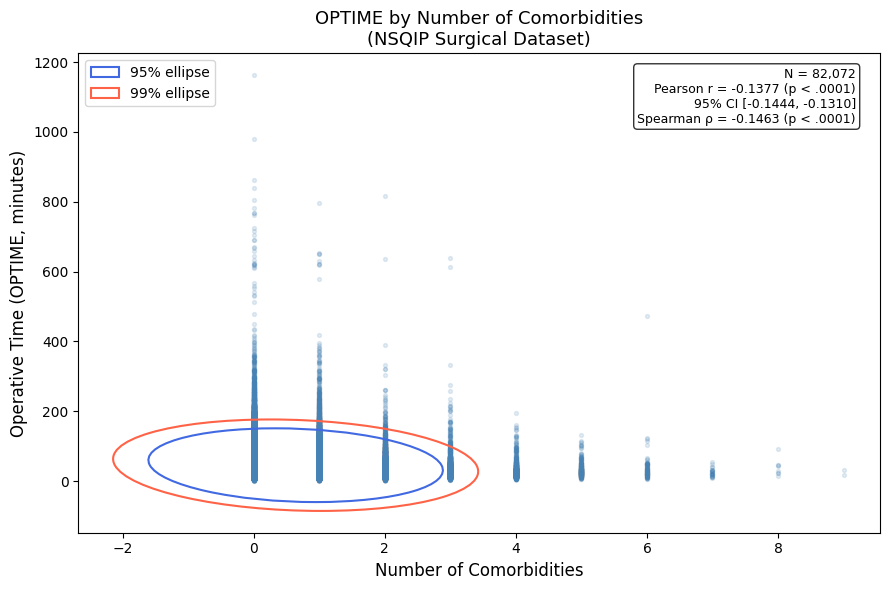

In [52]:
#| echo: false
#| output: false

# --- Ellipse helper ---
def confidence_ellipse(x, y, ax, pct, edgecolor):
    cov = np.cov(x, y)
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    chi2 = {0.95: 5.991, 0.99: 9.210}[pct]
    width, height = 2 * np.sqrt(vals * chi2)
    ellipse = patches.Ellipse(
        xy=(np.mean(x), np.mean(y)),
        width=width, height=height, angle=angle,
        edgecolor=edgecolor, fc='none', lw=1.5,
        label=f'{int(pct*100)}% ellipse'
    )
    ax.add_patch(ellipse)

# --- Plot ---
fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(x, y, alpha=0.15, s=8, color='steelblue', rasterized=True)
confidence_ellipse(x, y, ax, 0.95, edgecolor='royalblue')
confidence_ellipse(x, y, ax, 0.99, edgecolor='tomato')

ax.set_xlabel('Number of Comorbidities', fontsize=12)
ax.set_ylabel('Operation Time (OPTIME, minutes)', fontsize=12)
ax.set_title('OPTIME by Number of Comorbidities\n(NSQIP Surgical Dataset)', fontsize=13)
ax.legend(fontsize=10)

# Summary stats annotation
stats_text = (
    f"N = {n:,}\n"
    f"Pearson r = {pearson_r:.4f} (p < .0001)\n"
    f"95% CI [{ci_low:.4f}, {ci_high:.4f}]\n"
    f"Spearman ρ = {spearman_r:.4f} (p < .0001)"
)
ax.text(0.97, 0.97, stats_text, transform=ax.transAxes,
        fontsize=9, va='top', ha='right',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

## Graph

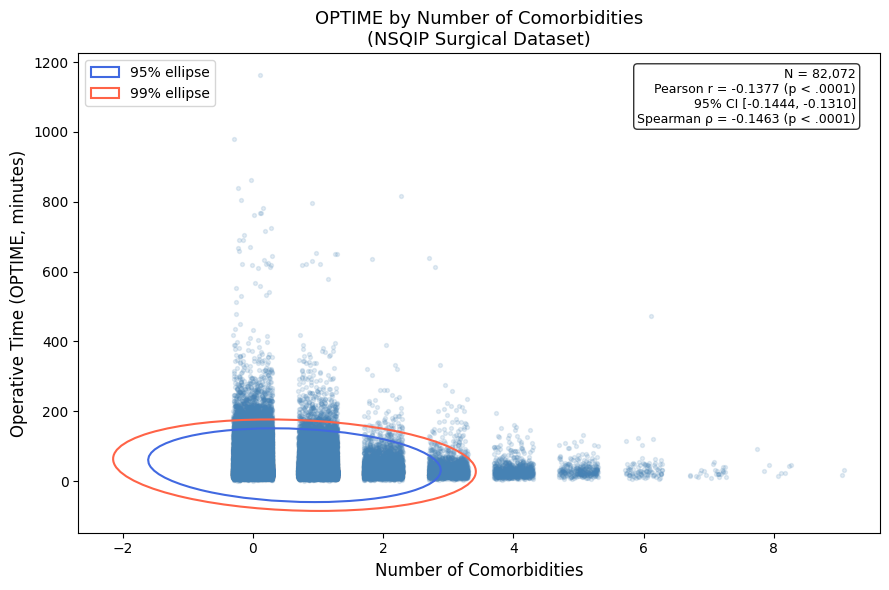

In [49]:
#| echo: false

rng = np.random.default_rng(42)
x_jittered = x + rng.uniform(-0.3, 0.3, size=len(x))

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(x_jittered, y, alpha=0.15, s=8, color='steelblue', rasterized=True)
confidence_ellipse(x, y, ax, 0.95, edgecolor='royalblue')
confidence_ellipse(x, y, ax, 0.99, edgecolor='tomato')

ax.set_xlabel('Number of Comorbidities', fontsize=12)
ax.set_ylabel('Operation Time (OPTIME, minutes)', fontsize=12)
ax.set_title('OPTIME by Number of Comorbidities\n(NSQIP Surgical Dataset)', fontsize=13)
ax.legend(fontsize=10)

stats_text = (
    f"N = {n:,}\n"
    f"Pearson r = {pearson_r:.4f} (p < .0001)\n"
    f"95% CI [{ci.low:.4f}, {ci.high:.4f}]\n"
    f"Spearman ρ = {spearman_r:.4f} (p < .0001)"
)
ax.text(0.97, 0.97, stats_text, transform=ax.transAxes,
        fontsize=9, va='top', ha='right',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

## Results Table

In [57]:
#| echo: false

# --- Results table ---
results = pd.DataFrame({
    'Method':      ['Pearson',  'Spearman'],
    'p-value':     [pearson_p,  spearman_p],
    'Correlation': [pearson_r,  spearman_r],
})

# We can add an interpretation column as well.
def interpret_r(r):
    r = abs(r)
    if r >= 0.8:   return 'Strong'
    elif r >= 0.4: return 'Moderate'
    elif r > 0:    return 'Weak'
    else:          return 'None'

results['Correlation'] = results['Correlation'].round(4)
results['Interpretation'] = results['Correlation'].apply(interpret_r)
results['p-value'] = results['p-value'].apply(lambda p: '< .0001' if p < .0001 else f'{p:.4f}')

# Display for the paper but hide the index so it looks more clean.
display(results.style.hide(axis='index'))

Method,p-value,Correlation,Interpretation
Pearson,< .0001,-0.137700,Weak
Spearman,< .0001,-0.146300,Weak


\newpage

# Exercise 3 - Summaries

## Journal Summary

Bivariate correlation analyses were conducted to examine the relationship between the number of comorbidities and operation duration (OPTIME) in a sample of $N = 82,072$ patients from the NSQIP dataset. Spearman's rank-order correlation was selected as the primary method given that comorbidity count is ordinal/discrete data and OPTIME is right-skewed; Pearson's r was computed for comparison. Both methods revealed a statistically significant but weak negative association (Pearson $r = −0.138$; Spearman $\rho = −0.146$; both $p < .0001$). The close agreement between the two coefficients suggests the relationship is both linear and monotonic.

The 95% confidence interval for Pearson's $r$ was $[−0.144, −0.131]$. Limitations include the right-skewed distribution of OPTIME and the uneven distribution of comorbidity counts — the majority of patients had 0–1 comorbidities — which may reduce the sensitivity of the correlation to detect relationships at higher comorbidity levels. Additionally, the summed comorbidity index treats all conditions equally, which may obscure the impact of specific high-severity diagnoses.

## Stakeholder Summary

We set out to determine whether patients with more pre-existing health conditions tend to have longer surgeries. Understanding this relationship could inform how hospitals schedule operating rooms, allocate staff, and assess surgical risk before procedures.

Our analysis of over 82,000 surgical cases found a small but statistically reliable tendency for patients with more health conditions to have slightly shorter operation times. However, the relationship is very weak, meaning that knowing a patient's comorbidity count tells us little about how long their surgery will actually take.

This finding suggests that comorbidity count alone should not be used as a primary driver for staffing or scheduling decisions. One limitation is that our measure treats all health conditions as equal, so a patient with controlled hypertension counts the same as one with kidney failure.